# Data Loading

In [1]:
import matplotlib.pyplot as plt
import os
import zipfile
try:
    import gdown
except ImportError:
    !pip install gdown

def download_dataset_from_google_drive(google_file_id: str, output_file_name: str, quiet_download: bool) -> str:
    file_path = f'./{output_file_name}'

    if not os.path.exists(file_path):
        gdown.download(id=google_file_id, output=output_file_name, quiet=quiet_download)
    else:
        print(f"{output_file_name} already exists!")
    if os.path.exists(file_path):
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall('./')
    return file_path

In [2]:
#https://drive.google.com/file/d/1ke6APNDoRqSCSoaHbncT_WpmSNCT9sbh/view?usp=sharing
data_path = "1ke6APNDoRqSCSoaHbncT_WpmSNCT9sbh"

In [3]:
data_dir = download_dataset_from_google_drive(data_path, "data.zip", True)

In [4]:
import os
import numpy as np
import random

def read_text_files(folder_path):
    """Reads all text files in the given folder."""
    contents = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        # Check if it's a file and has .txt extension
        if os.path.isfile(file_path) and filename.endswith(".txt"):
            with open(file_path, "r") as file:
                content = file.read()
                contents.append(content)
    return contents

In [5]:
# Training set
train_positive_reviews = read_text_files("aclImdb/train/pos/")
train_negative_reviews = read_text_files("aclImdb/train/neg/")
train_reviews = train_positive_reviews + train_negative_reviews
y_train = np.array([1]*12500 + [0]*12500)
#Test set
test_positive_reviews = read_text_files("aclImdb/test/pos/")
test_negative_reviews = read_text_files("aclImdb/test/neg/")
test_reviews = test_positive_reviews + test_negative_reviews
y_test = np.array([1]*12500 + [0]*12500)


# Data Processing

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [7]:
vocabulary = 10000
tokenizer = Tokenizer(num_words = vocabulary)

In [8]:
tokenizer.fit_on_texts(train_reviews)

In [9]:
word_index = tokenizer.word_index

In [10]:
sequences_train = tokenizer.texts_to_sequences(train_reviews)

In [11]:
word_num = 500
x_train = pad_sequences(sequences_train, maxlen = word_num)

## Split Training and Validation Data and Process Test Data

In [12]:
n = x_train.shape[0]
np.random.seed(42)
rand_perm = np.random.permutation(n)
n_valid = int(n * 0.2)
labels_train = np.array(y_train)
x_valid = x_train[rand_perm[0:n_valid], :]
y_valid = labels_train[rand_perm[0:n_valid]]
x_train = x_train[rand_perm[n_valid:n], :]
y_train = labels_train[rand_perm[n_valid:n]]

In [13]:
word_index = tokenizer.word_index
sequences_test = tokenizer.texts_to_sequences(test_reviews)
word_num = 500
x_test = pad_sequences(sequences_test, maxlen=word_num)

# Build a Stacked RNN model

In [14]:
from keras.models import Sequential
from keras.layers import LSTM, Embedding, Dense, Input

vocabulary = 10000
embedding_dim = 32
word_num = 500
state_dim = 32

model = Sequential()
model.add(Input((word_num, )))
model.add(Embedding(vocabulary, embedding_dim))
model.add(LSTM(state_dim, return_sequences=True, dropout=0.2))
model.add(LSTM(state_dim, return_sequences=True, dropout=0.2))
model.add(LSTM(state_dim, return_sequences=False, dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 500, 32)             │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 500, 32)             │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 344,993 (1.32 MB)

 Trainable params: 344,993 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from keras import optimizers

epochs = 10

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss = "binary_crossentropy", metrics = ['acc'])

In [16]:
history = model.fit(x_train, y_train, epochs=epochs, batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - acc: 0.6106 - loss: 0.6186 - val_acc: 0.8260 - val_loss: 0.3965
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - acc: 0.8646 - loss: 0.3482 - val_acc: 0.8570 - val_loss: 0.3448
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - acc: 0.8954 - loss: 0.2817 - val_acc: 0.8826 - val_loss: 0.3033
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - acc: 0.9082 - loss: 0.2446 - val_acc: 0.8764 - val_loss: 0.3011
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - acc: 0.9240 - loss: 0.2098 - val_acc: 0.8778 - val_loss: 0.3253
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - acc: 0.9333 - loss: 0.1908 - val_acc: 0.8776 - val_loss: 0.2970
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - acc: 0.9398 - loss: 0.1716 - val_acc: 0.8574 - val_loss: 0.3498
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - acc: 0.9410 - loss: 0.1688 - val_acc: 0.8584 - val_loss: 0.3391
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

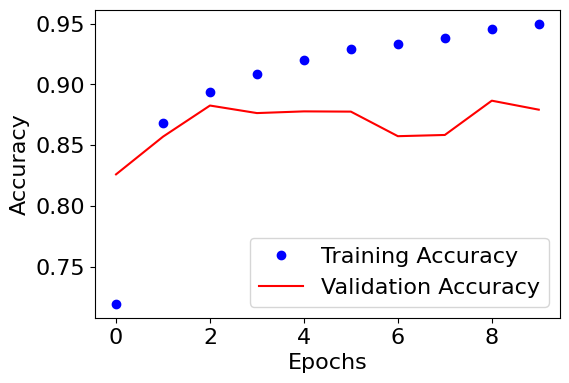

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4))
epochs_list = range(epochs)
train_acc = history.history['acc']
valid_acc = history.history['val_acc']
plt.plot(epochs_list, train_acc, 'bo', label='Training Accuracy')
plt.plot(epochs_list, valid_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

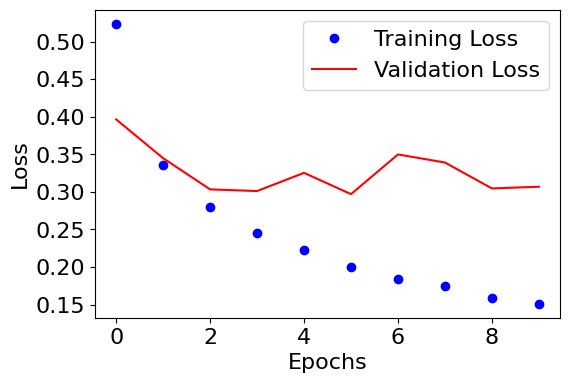

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4))
epochs_list = range(epochs)
train_loss = history.history['loss']
valid_loss = history.history['val_loss']
plt.plot(epochs_list, train_loss, 'bo', label='Training Loss')
plt.plot(epochs_list, valid_loss, 'r', label='Validation Loss')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

In [19]:
loss_and_acc = model.evaluate(x_test, y_test)
print('loss = ' + str(loss_and_acc[0]))
print('acc = ' + str(loss_and_acc[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - acc: 0.8457 - loss: 0.3758
loss = 0.3255118429660797
acc = 0.8733599781990051


# Build an Bidirectional LSTM model

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Embedding, Dense, Input, Bidirectional

vocabulary = 10000
embedding_dim = 32
word_num = 500
state_dim = 32

model = Sequential()
model.add(Input((word_num, )))
model.add(Embedding(vocabulary, embedding_dim))
model.add(Bidirectional(LSTM(state_dim, return_sequences=False, dropout=0.2)))
model.add(Dense(1, activation='sigmoid'))

model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 336,705 (1.28 MB)

 Trainable params: 336,705 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import optimizers

epochs = 10

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0001),
              loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=epochs,
                    batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - acc: 0.5090 - loss: 0.6930 - val_acc: 0.5384 - val_loss: 0.6921
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.5711 - loss: 0.6903 - val_acc: 0.6846 - val_loss: 0.6457
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - acc: 0.6937 - loss: 0.6133 - val_acc: 0.7958 - val_loss: 0.5034
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.8078 - loss: 0.4602 - val_acc: 0.8374 - val_loss: 0.3910
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.8619 - loss: 0.3486 - val_acc: 0.8554 - val_loss: 0.3496
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.8888 - loss: 0.2902 - val_acc: 0.8658 - val_loss: 0.3162
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - acc: 0.8991 - loss: 0.2642 - val_acc: 0.8764 - val_loss: 0.3092
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.9100 - loss: 0.2388 - val_acc: 0.8786 - val_loss: 0.3005
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
loss_and_acc = model.evaluate(x_test, y_test)
print('loss = ' + str(loss_and_acc[0]))
print('acc = ' + str(loss_and_acc[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.8405 - loss: 0.3759
loss = 0.3027842044830322
acc = 0.8746399879455566
